<a href="https://colab.research.google.com/github/sleepymor/image-recognition-learning/blob/main/Image_Detection_Using_pyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision # Added for make_grid

In [104]:
# 1. Define Transformations
# Resizing to 224x224 is standard for ResNet models
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


Detected Classes: ['Cat', 'Dog']
Using device: cuda:0
Training set size: 1
Validation set size: 1

Original Image (Class: Cat):


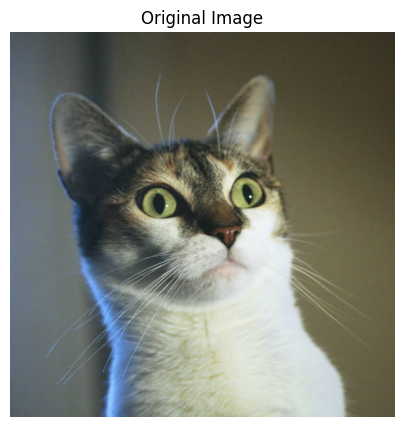


Displaying 5 augmented variants of the original image (Class: Cat):
Variant 1 Tensor Shape: torch.Size([3, 224, 224])
Variant 1 Tensor Type: torch.float32


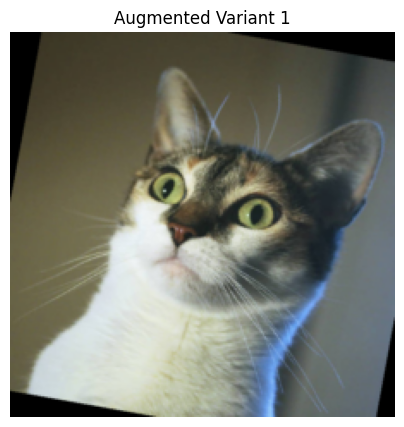

Variant 2 Tensor Shape: torch.Size([3, 224, 224])
Variant 2 Tensor Type: torch.float32


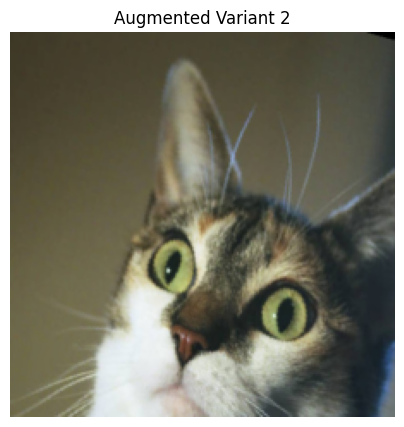

Variant 3 Tensor Shape: torch.Size([3, 224, 224])
Variant 3 Tensor Type: torch.float32


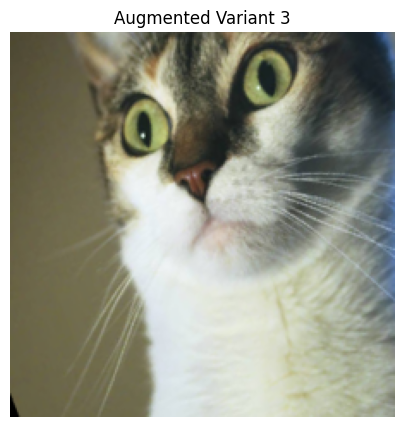

Variant 4 Tensor Shape: torch.Size([3, 224, 224])
Variant 4 Tensor Type: torch.float32


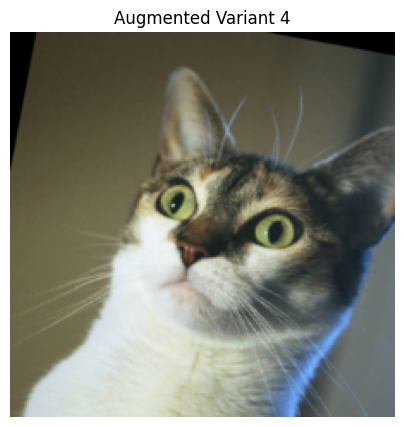

Variant 5 Tensor Shape: torch.Size([3, 224, 224])
Variant 5 Tensor Type: torch.float32


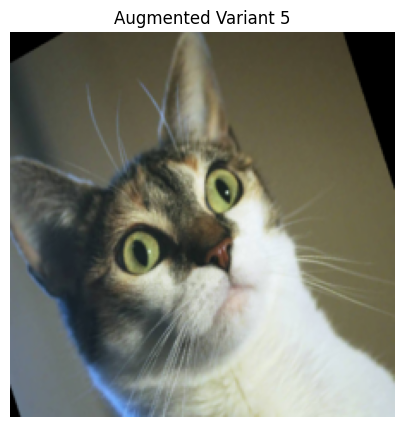

In [105]:
# 2. Load Dataset
# Replace 'image_test' with the actual path in your Colab (e.g., '/content/image_test')
data_dir = '/content/drive/MyDrive/image_test'

# Create the full dataset with only base transformations to determine its size
full_dataset = datasets.ImageFolder(data_dir, transform=val_transforms) # Using val_transforms as it doesn't include augmentation

# Define sizes for training and validation sets
total_size = len(full_dataset)
train_size = int(0.8 * total_size) # 80% for training
val_size = total_size - train_size # Remaining for validation

# Split the dataset randomly
train_data, val_data = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Apply the correct transformations to the respective splits
train_data.dataset.transform = train_transforms
val_data.dataset.transform = val_transforms

# Create DataLoaders for both training and validation sets
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=False)

class_names = full_dataset.classes # Use full_dataset to get class names
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Detected Classes: {class_names}")
print(f"Using device: {device}")
print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")

# Visualize images after preprocessing
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Clip values to [0, 1] for proper display
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off') # Turn off axis

# Get a path to an original image and its label
# We'll pick the first image in the original full_dataset for demonstration of augmentation
original_image_path, original_label_idx = full_dataset.samples[0]
original_image = Image.open(original_image_path).convert('RGB')
original_class_name = class_names[original_label_idx]

print(f"\nOriginal Image (Class: {original_class_name}):")
plt.figure(figsize=(5,5))
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')
plt.show()

print(f"\nDisplaying 5 augmented variants of the original image (Class: {original_class_name}):")
for i in range(5): # Generate 5 augmented variants
    augmented_image_tensor = train_transforms(original_image)
    print(f"Variant {i+1} Tensor Shape: {augmented_image_tensor.shape}")
    print(f"Variant {i+1} Tensor Type: {augmented_image_tensor.dtype}")
    plt.figure(figsize=(5,5))
    imshow(augmented_image_tensor, title=f"Augmented Variant {i+1}")
    plt.show()

In [106]:
# Load pre-trained ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze early layers to keep pre-trained features (optional)
for param in model.parameters():
    param.requires_grad = False

# Redefine the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [107]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    running_corrects = 0

    # Training phase
    for inputs, labels in train_dataloader: # Use train_dataloader here
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_data) # Use len(train_data) for train loss
    epoch_train_acc = running_corrects.double() / len(train_data) # Use len(train_data) for train accuracy

    # Validation phase
    model.eval() # Set model to evaluate mode
    val_running_loss = 0.0
    val_running_corrects = 0
    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in val_dataloader: # Use val_dataloader here
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_running_loss / len(val_data) # Use len(val_data) for val loss
    epoch_val_acc = val_running_corrects.double() / len(val_data) # Use len(val_data) for val accuracy

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f}')

Epoch 1/5 | Train Loss: 0.7188 Train Acc: 0.0000 | Val Loss: 0.6722 Val Acc: 1.0000
Epoch 2/5 | Train Loss: 0.3386 Train Acc: 1.0000 | Val Loss: 1.2172 Val Acc: 0.0000
Epoch 3/5 | Train Loss: 0.1503 Train Acc: 1.0000 | Val Loss: 1.9066 Val Acc: 0.0000
Epoch 4/5 | Train Loss: 0.0686 Train Acc: 1.0000 | Val Loss: 2.6668 Val Acc: 0.0000
Epoch 5/5 | Train Loss: 0.0335 Train Acc: 1.0000 | Val Loss: 3.4300 Val Acc: 0.0000


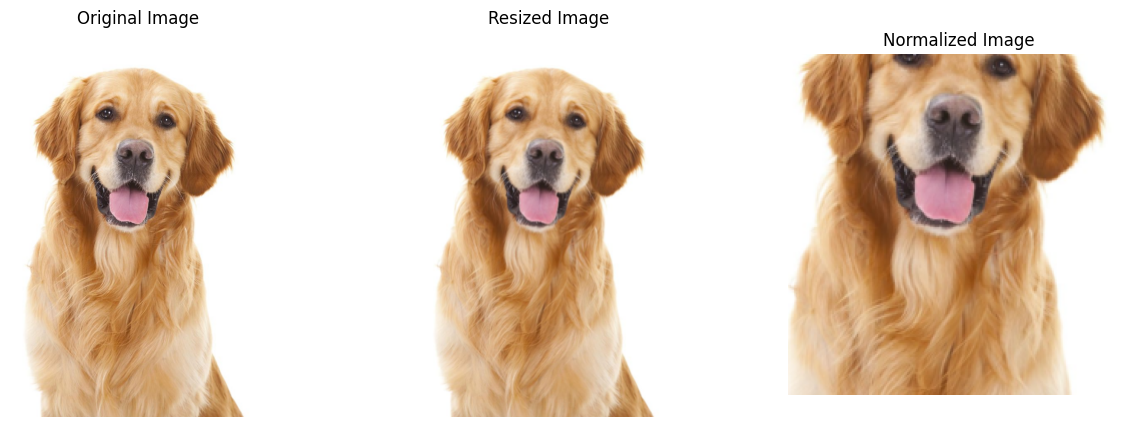

Prediction: Dog


In [108]:
from PIL import Image
import numpy as np

def predict_image(image_path):
    model.eval()
    img = Image.open(image_path)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    # Apply Resize transform only for visualization (using val_transforms for consistency)
    resized_img = val_transforms.transforms[0](img) # Get the Resize transform
    plt.subplot(1, 3, 2)
    plt.imshow(resized_img)
    plt.title('Resized Image')
    plt.axis('off')

    # Apply all validation transforms for model input
    img_t = val_transforms(img).unsqueeze(0).to(device)

    # For normalized image, we need to reverse normalize for display
    # Create a copy to avoid modifying the tensor used for prediction
    normalized_img_display = img_t.squeeze(0).cpu().clone()
    for t, m, s in zip(normalized_img_display, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]):
        t.mul_(s).add_(m)
    plt.subplot(1, 3, 3)
    plt.imshow(np.transpose(normalized_img_display.numpy(), (1, 2, 0)))
    plt.title('Normalized Image')
    plt.axis('off')
    plt.show()

    with torch.no_grad():
        outputs = model(img_t)
        _, preds = torch.max(outputs, 1)

    print(f"Prediction: {class_names[preds[0]]}")

predict_image('/content/3eba70b7600c637b789ba2f4917de26c.jpg')